# 00. EDA 개요

In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 17)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1,age1_tminus1,income1_tminus1,job1_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0,43,7,1
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0,44,8,1
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0,45,8,1
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,46,9,1
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0,47,9,1


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


In [3]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 서비스 가입 여부",
    "a03026_tminus1": "데이터 무제한 서비스 가입 여부",
    "c01002_tminus1": "월평균 휴대폰 이용 총 금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "휴대폰 결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))

# 00 EDA Overview

## [ 개요 ]

본 노트북은 KMP 2020~2025 데이터를 이용해 생성한 통신사 이탈 예측용 데이터셋의 기본 구조와 분포를 확인하기 위한 EDA 노트북이다.

주요 확인 내용은 다음과 같다.

- 데이터 기본 구조 확인
- 연도 전환 구조 확인
- 라벨 분포 확인
- 핵심 변수 분포 확인
- 변수 간 기초 관계 확인

본 EDA는 깊은 탐색보다는, 모델링 전에 데이터 특성과 라벨 구조를 점검하는 목적에 초점을 둔다.

In [4]:
# ============================================================
# 3. 데이터 기본 구조 확인
# ============================================================
display_columns = [FEATURE_LABEL_MAP.get(col, TARGET_LABEL_MAP.get(col, col)) for col in df.columns]

print("행 개수:", df.shape[0])
print("열 개수:", df.shape[1])

print("\n컬럼 목록(표시용 이름)")
for col in display_columns:
    print("-", col)

print("\n기본 정보")
display(df.info())

print("\n기초 통계량")
desc_df = df.describe(include="all").T
desc_df.index = [FEATURE_LABEL_MAP.get(idx, TARGET_LABEL_MAP.get(idx, idx)) for idx in desc_df.index]
display(desc_df)

행 개수: 41299
열 개수: 17

컬럼 목록(표시용 이름)
- pid
- year_t0
- year_t1
- telco_t0
- telco_t1
- 전체 통신사 변경 여부
- 메이저 → 알뜰폰 이동 여부
- 스마트폰 구분
- 음성 무제한 서비스 가입 여부
- 데이터 무제한 서비스 가입 여부
- 월평균 휴대폰 이용 총 금액
- 월평균 기기 할부금
- 휴대폰 결합상품 가입 여부
- 휴대폰 요금 부담자
- 나이
- 개인 월평균 소득
- 직업 유무

기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41299 entries, 0 to 41298
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pid              41299 non-null  int64  
 1   year_t0          41299 non-null  int64  
 2   year_t1          41299 non-null  int64  
 3   telco_t0         41299 non-null  float64
 4   telco_t1         41299 non-null  float64
 5   churn_any        41299 non-null  int64  
 6   churn_to_mvno    41299 non-null  int64  
 7   a03002_tminus1   41299 non-null  float64
 8   a03024_tminus1   41299 non-null  float64
 9   a03026_tminus1   41299 non-null  float64
 10  c01002_tminus1   41299 non-null  float64
 11  c01004_tminus1   41299 non-nu

None


기초 통계량


,count,mean,std,min,25%,50%,75%,max
pid,41299.0,4.961549e+07,3.843270e+07,10001.0,15435001.5,50360002.0,70220001.0,118330001.0
year_t0,41299.0,2.021924e+03,1.398654e+00,2020.0,2021.0,2022.0,2023.0,2024.0
year_t1,41299.0,2.022924e+03,1.398654e+00,2021.0,2022.0,2023.0,2024.0,2025.0
telco_t0,41299.0,1.799148e+00,8.652062e-01,1.0,1.0,2.0,3.0,4.0
telco_t1,41299.0,1.823749e+00,8.797096e-01,1.0,1.0,2.0,3.0,4.0
전체 통신사 변경 여부,41299.0,3.627691e-01,4.808048e-01,0.0,0.0,0.0,1.0,1.0
메이저 → 알뜰폰 이동 여부,41299.0,1.247004e-02,1.109722e-01,0.0,0.0,0.0,0.0,1.0
스마트폰 구분,41299.0,3.119979e+00,7.417930e-01,1.0,3.0,3.0,4.0,4.0
음성 무제한 서비스 가입 여부,41299.0,7.111552e-01,4.532311e-01,0.0,0.0,1.0,1.0,1.0
데이터 무제한 서비스 가입 여부,41299.0,3.729872e-01,4.836046e-01,0.0,0.0,0.0,1.0,1.0


## [ 해석 ]

데이터셋은 전처리 후 예측에 사용할 수 있는 형태로 정리되어 있으며, 각 행은 한 개인의 전년(`t-1`)에서 다음 해(`t`)로의 전환을 나타낸다.

이 단계에서는 전체 행 수, 컬럼 수, 자료형, 기초 통계량을 확인하여 데이터가 정상적으로 생성되었는지 점검한다.

,year_t0,year_t1,count
0,2020,2021,8612
1,2021,2022,8708
2,2022,2023,8714
3,2023,2024,7730
4,2024,2025,7535


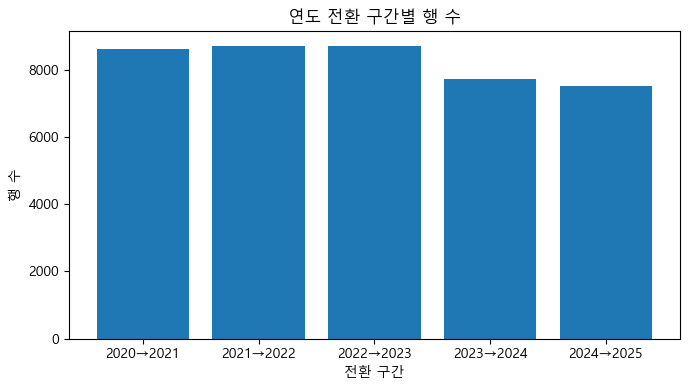

In [5]:
# ============================================================
# 4. 연도 전환 구조 확인
# ============================================================
transition_counts = (
    df.groupby(["year_t0", "year_t1"])
    .size()
    .reset_index(name="count")
)

display(transition_counts)

plt.figure(figsize=(7, 4))
labels = transition_counts["year_t0"].astype(str) + "→" + transition_counts["year_t1"].astype(str)
plt.bar(labels, transition_counts["count"])
plt.title("연도 전환 구간별 행 수")
plt.xlabel("전환 구간")
plt.ylabel("행 수")
plt.tight_layout()
plt.show()

## [ 해석 ]

연도 전환 구조를 확인함으로써 데이터가 `pid` 기준으로 정상적으로 연결되었는지 점검할 수 있다.

각 행은 `year_t0 → year_t1` 형태의 전환을 의미하며, 전환 구간별 행 수를 확인하면 특정 연도 구간에 데이터가 과도하게 몰려 있거나 누락된 부분이 있는지 파악할 수 있다.


[전체 통신사 변경 여부]


,값,빈도
0,0,26317
1,1,14982


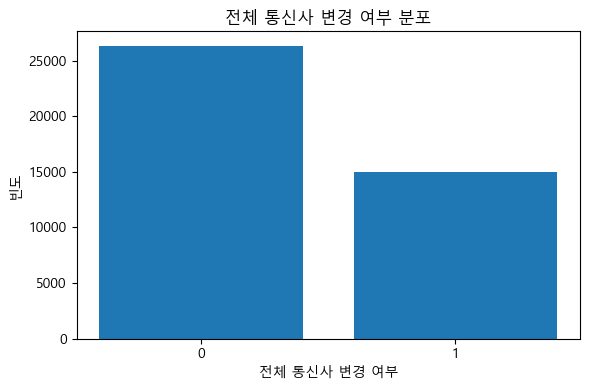


[메이저 → 알뜰폰 이동 여부]


,값,빈도
0,0,40784
1,1,515


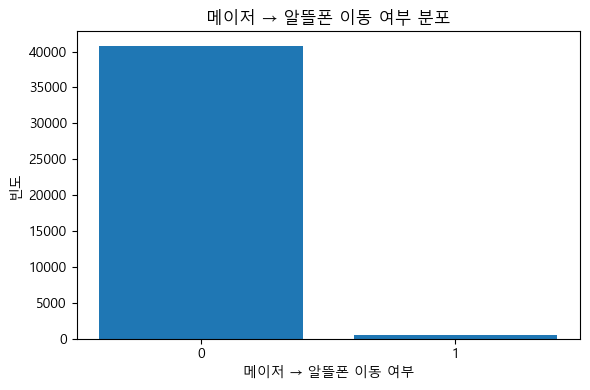


[해석] 라벨 분포
- 전체 통신사 변경 여부는 비교적 충분한 양성 비율을 보여 예측 가능한 문제로 볼 수 있다.
- 반면 메이저 → 알뜰폰 이동 여부는 매우 희소한 이벤트라서 클래스 불균형 문제가 크다.
- 따라서 churn_to_mvno는 Accuracy보다 Recall, F1, PR-AUC 중심 해석이 더 중요하다.


In [6]:
# ============================================================
# 5. 라벨 분포 확인
# ============================================================
target_cols = ["churn_any", "churn_to_mvno"]

for col in target_cols:
    print(f"\n[{TARGET_LABEL_MAP[col]}]")

    value_count_df = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("값")
        .reset_index(name="빈도")
    )
    display(value_count_df)

    plt.figure(figsize=(6, 4))
    plt.bar(value_count_df["값"].astype(str), value_count_df["빈도"])
    plt.title(f"{TARGET_LABEL_MAP[col]} 분포")
    plt.xlabel(TARGET_LABEL_MAP[col])
    plt.ylabel("빈도")
    plt.tight_layout()
    plt.show()

print("\n[해석] 라벨 분포")
print("- 전체 통신사 변경 여부는 비교적 충분한 양성 비율을 보여 예측 가능한 문제로 볼 수 있다.")
print("- 반면 메이저 → 알뜰폰 이동 여부는 매우 희소한 이벤트라서 클래스 불균형 문제가 크다.")
print("- 따라서 churn_to_mvno는 Accuracy보다 Recall, F1, PR-AUC 중심 해석이 더 중요하다.")

## [ 해석 ]

`churn_any`와 `churn_to_mvno`의 라벨 분포를 확인하면 두 예측 문제의 난이도 차이를 파악할 수 있다.

실제 데이터에서 `churn_any`는 약 36% 수준의 양성 비율을 보여, `churn_to_mvno`보다 상대적으로 덜 희소한 예측 문제임을 확인할 수 있다.

반면 `churn_to_mvno`는 약 1% 수준의 매우 희소한 이벤트로 나타나 극심한 클래스 불균형 문제를 가진다.

따라서 이러한 데이터 구조에서는 단순 Accuracy 지표만으로 모델 성능을 평가할 경우 실제 예측 능력을 과대평가할 가능성이 있다.
특히 `churn_to_mvno`는 Accuracy보다 Precision, Recall, PR-AUC, F1을 함께 고려하는 것이 중요하다.


[스마트폰 구분]


,값,빈도
0,3G 스마트폰,571
1,5G 스마트폰,13566
2,LTE 스마트폰,7469
3,LTE-A 스마트폰,19693


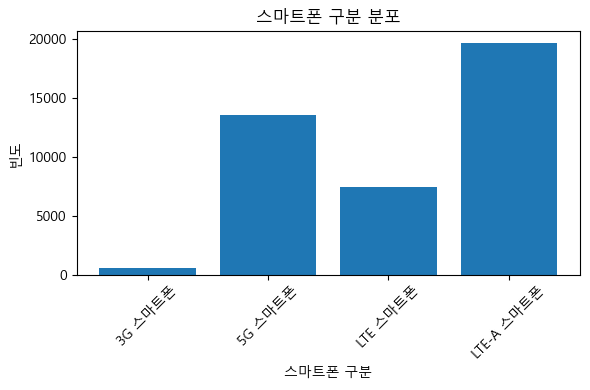


[음성 무제한 서비스 가입 여부]


,값,빈도
0,가입,29370
1,미가입,11929


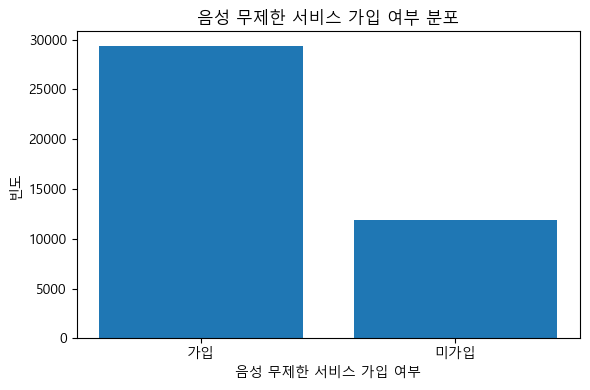


[데이터 무제한 서비스 가입 여부]


,값,빈도
0,가입,15404
1,미가입,25895


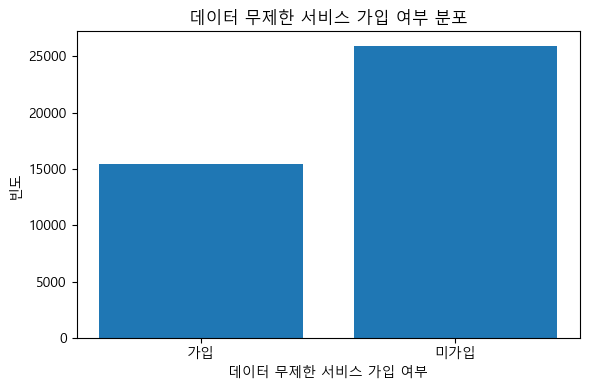


[월평균 휴대폰 이용 총 금액]


,값,빈도
0,1.0,299
1,2.0,1877
2,3.0,3977
3,4.0,9241
4,5.0,8747
5,6.0,7870
6,7.0,4971
7,8.0,2115
8,9.0,1259
9,10.0,346


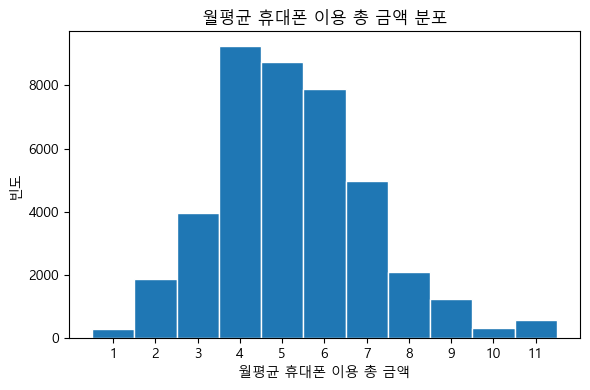


[월평균 기기 할부금]


,값,빈도
0,1.0,25733
1,2.0,8867
2,3.0,4520
3,4.0,1364
4,5.0,447
5,6.0,226
6,7.0,56
7,8.0,28
8,9.0,21
9,10.0,5


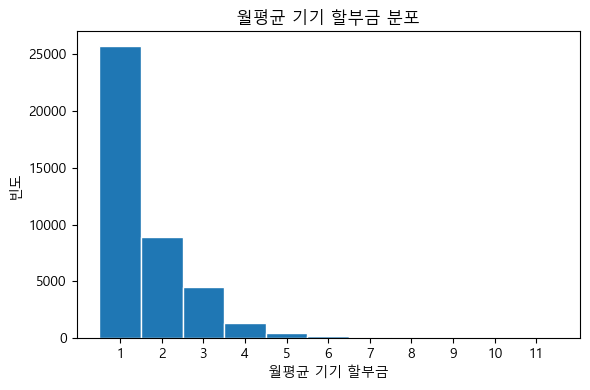


[휴대폰 결합상품 가입 여부]


,값,빈도
0,가입,31414
1,미가입,9885


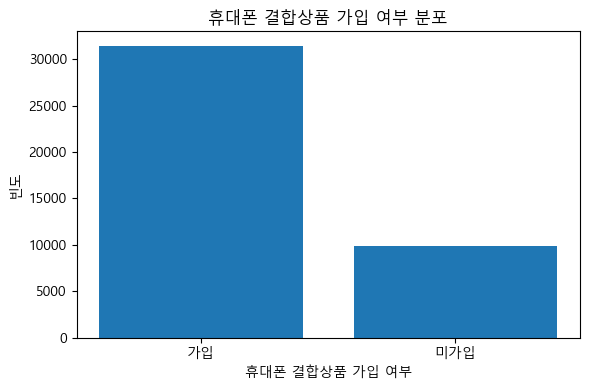


[휴대폰 요금 부담자]


,값,빈도
0,배우자,51
1,본인,28039
2,부모/조부모,115
3,자녀/자녀배우자,12983
4,형제/자매,111


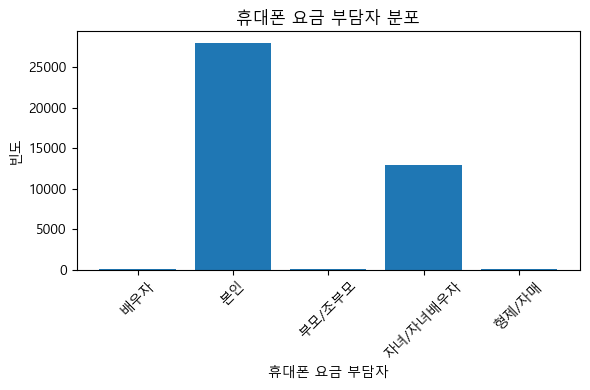


[나이]


,값,빈도
0,6,1
1,7,19
2,8,47
3,9,91
4,10,165
5,11,226
6,12,272
7,13,318
8,14,377
9,15,417


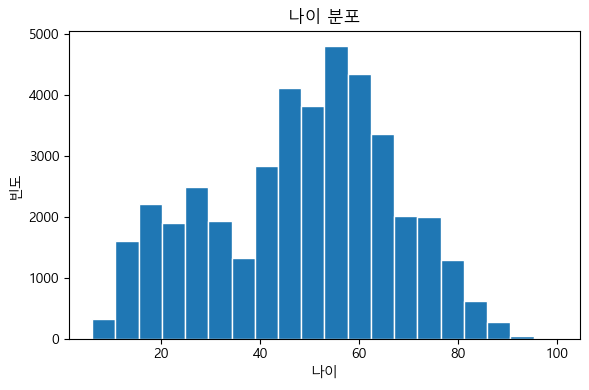


[개인 월평균 소득]


,값,빈도
0,1,12967
1,2,1917
2,3,2145
3,4,1854
4,5,3824
5,6,4031
6,7,5224
7,8,2856
8,9,2713
9,10,1141


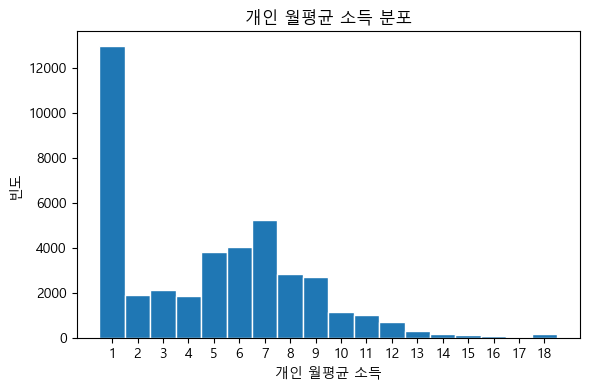


[직업 유무]


,값,빈도
0,직업 없음,16196
1,직업 있음,25103


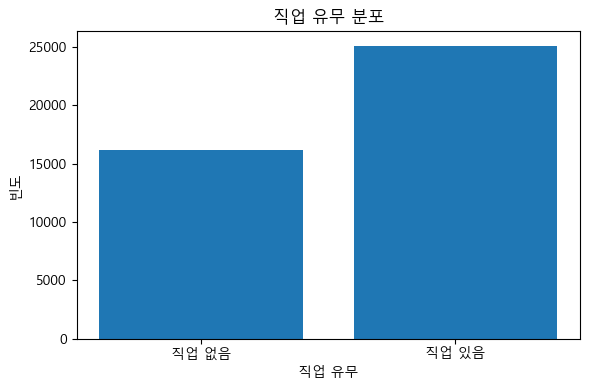


[해석] 핵심 변수 확장
- 기존 통신 이용 특성 7개 변수에 나이, 개인 월평균 소득, 직업 유무가 추가되었다.
- 따라서 이번 EDA는 통신 사용 패턴뿐 아니라 생애주기와 경제적 배경 차이까지 함께 보는 구조가 되었다.
- 코드형 범주 변수는 숫자 크기보다 각 범주의 의미를 중심으로 해석하는 것이 적절하다.


In [15]:
# ============================================================
# 6. 핵심 변수 분포 확인
# ============================================================
feature_cols = [
    "a03002_tminus1",
    "a03024_tminus1",
    "a03026_tminus1",
    "c01002_tminus1",
    "c01004_tminus1",
    "c02003_tminus1",
    "c02001_tminus1",
    "age1_tminus1",
    "income1_tminus1",
    "job1_tminus1"
]

binary_like_cols = [
    "a03024_tminus1",
    "a03026_tminus1",
    "c02003_tminus1",
    "job1_tminus1"
]

categorical_like_cols = [
    "a03002_tminus1",
    "c02001_tminus1"
]

# 코드형 변수 라벨 매핑
smartphone_map = {
    1: "3G 스마트폰",
    2: "LTE 스마트폰",
    3: "LTE-A 스마트폰",
    4: "5G 스마트폰"
}

payer_map = {
    1: "본인",
    2: "부모/조부모",
    3: "배우자",
    4: "자녀/자녀배우자",
    5: "형제/자매",
    6: "기타"
}

binary_map = {
    0: "미가입",
    1: "가입"
}

job_map = {
    0: "직업 없음",
    1: "직업 있음"
}

for col in feature_cols:
    display_name = rename_feature_label(col)

    print(f"\n[{display_name}]")

    plot_series = df[col].copy()

    if col == "a03002_tminus1":
        plot_series = plot_series.map(smartphone_map)
    elif col == "c02001_tminus1":
        plot_series = plot_series.map(payer_map)
    elif col in ["a03024_tminus1", "a03026_tminus1", "c02003_tminus1"]:
        plot_series = plot_series.map(binary_map)
    elif col == "job1_tminus1":
        plot_series = plot_series.map(job_map)

    value_count_df = (
        plot_series
        .value_counts(dropna=False)
        .sort_index()
        .head(20)
        .rename_axis("값")
        .reset_index(name="빈도")
    )
    display(value_count_df)

    plt.figure(figsize=(6, 4))

    if col in binary_like_cols or col in categorical_like_cols:
        plt.bar(value_count_df["값"].astype(str), value_count_df["빈도"])
    else:
        unique_len = df[col].nunique()

        if unique_len < 30:
            min_val = int(df[col].dropna().min())
            max_val = int(df[col].dropna().max())

            bins = np.arange(min_val - 0.5, max_val + 1.5, 1)
            plt.hist(df[col].dropna(), bins=bins, edgecolor="white")

            plt.xticks(range(min_val, max_val + 1))
        else:
            plt.hist(df[col].dropna(), bins=20, edgecolor="white")

    plt.title(f"{display_name} 분포")
    plt.xlabel(display_name)
    plt.ylabel("빈도")
    plt.xticks(rotation=45 if col in categorical_like_cols else 0)
    plt.tight_layout()
    plt.show()

print("\n[해석] 핵심 변수 확장")
print("- 기존 통신 이용 특성 7개 변수에 나이, 개인 월평균 소득, 직업 유무가 추가되었다.")
print("- 따라서 이번 EDA는 통신 사용 패턴뿐 아니라 생애주기와 경제적 배경 차이까지 함께 보는 구조가 되었다.")
print("- 코드형 범주 변수는 숫자 크기보다 각 범주의 의미를 중심으로 해석하는 것이 적절하다.")

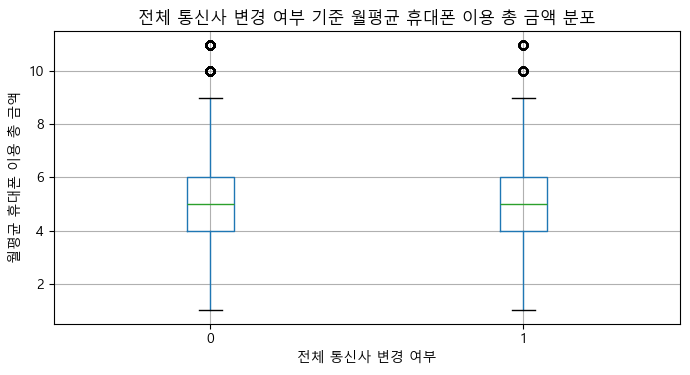

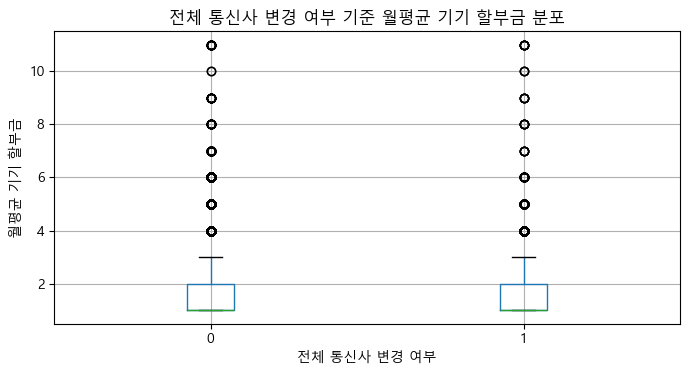

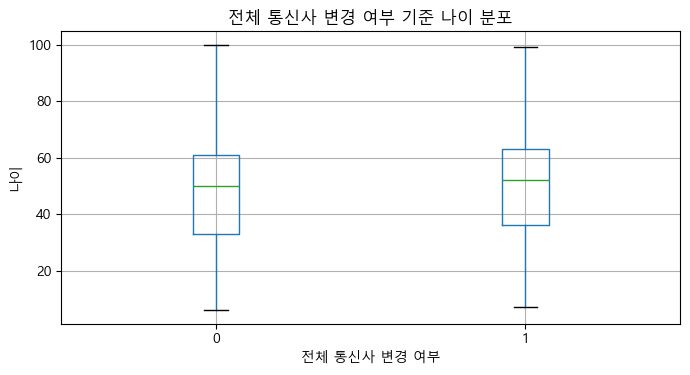

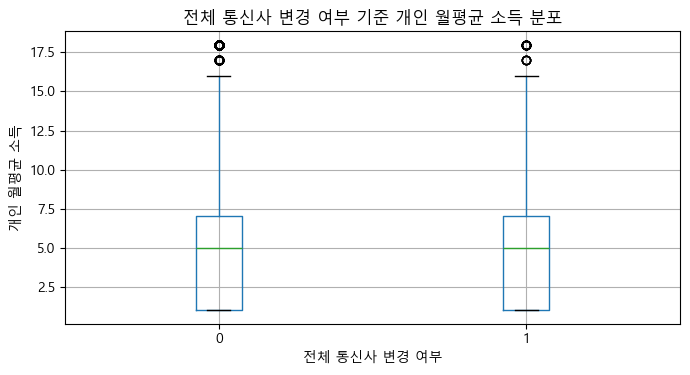

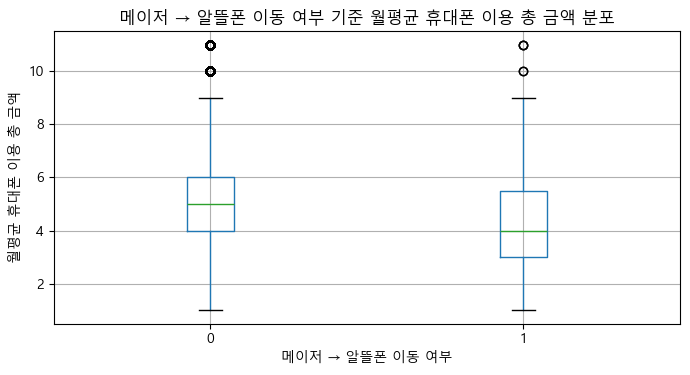

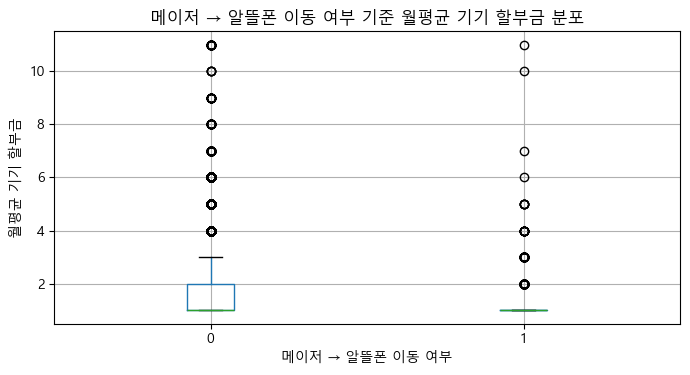

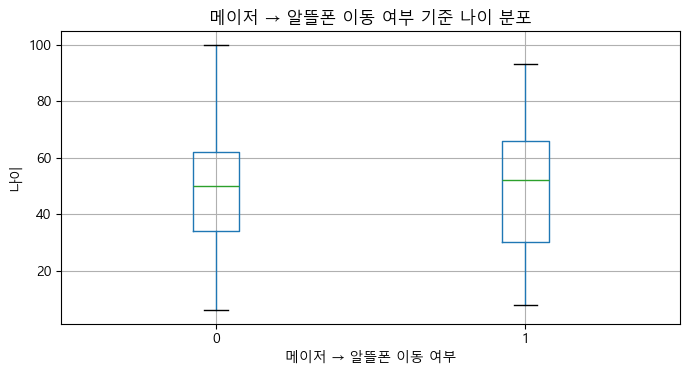

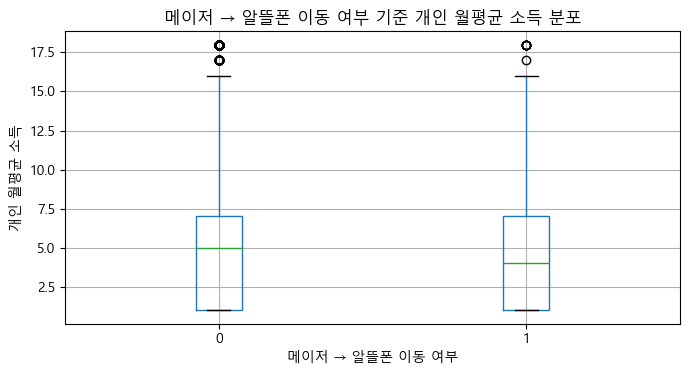

In [8]:
# ============================================================
# 추가. 라벨별 수치형 변수 분포 비교
# ============================================================
numeric_feature_cols = [
    "c01002_tminus1",
    "c01004_tminus1",
    "age1_tminus1",
    "income1_tminus1"
]

for target in ["churn_any", "churn_to_mvno"]:
    for col in numeric_feature_cols:
        fig, ax = plt.subplots(figsize=(7, 4))
        df.boxplot(column=col, by=target, ax=ax)

        ax.set_title(f"{TARGET_LABEL_MAP[target]} 기준 {rename_feature_label(col)} 분포")
        fig.suptitle("")
        ax.set_xlabel(TARGET_LABEL_MAP[target])
        ax.set_ylabel(rename_feature_label(col))

        plt.tight_layout()
        plt.show()

## [ 해석 ]

핵심 변수 분포를 확인하면 변수의 값 범위와 치우침 정도를 파악할 수 있다.

다만 변수마다 성격이 다르므로 해석 방식도 구분할 필요가 있다.

- 이진형 변수는 가입/미가입 같은 집단 비중 중심으로 보는 것이 적절하다.
- 수치형 변수는 값의 분포와 라벨별 차이를 함께 보는 것이 적절하다.
- 코드형 범주 변수는 숫자 크기 자체보다 범주의 의미를 중심으로 해석해야 한다.

따라서 이번 분포 확인은 변수의 통계적 특성을 정리하고, 이후 모델 해석에서 어떤 방식으로 읽어야 하는지 감을 잡는 단계로 볼 수 있다.


[음성 무제한 서비스 가입 여부 - 전체 통신사 변경 여부]


,구분,이탈 비율
0,미가입,0.365580
1,가입,0.361628


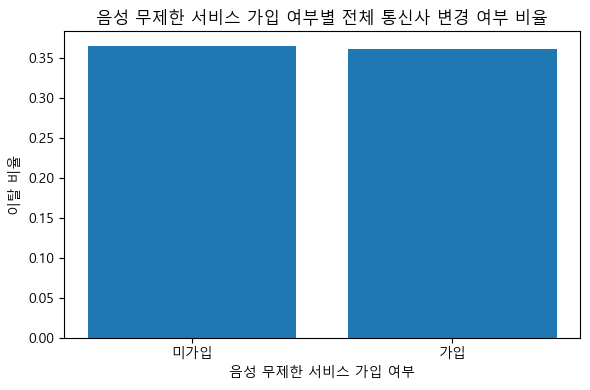


[데이터 무제한 서비스 가입 여부 - 전체 통신사 변경 여부]


,구분,이탈 비율
0,미가입,0.370187
1,가입,0.350299


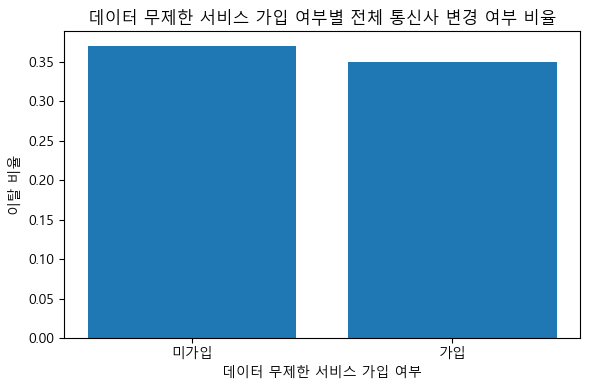


[휴대폰 결합상품 가입 여부 - 전체 통신사 변경 여부]


,구분,이탈 비율
0,미가입,0.385432
1,가입,0.355638


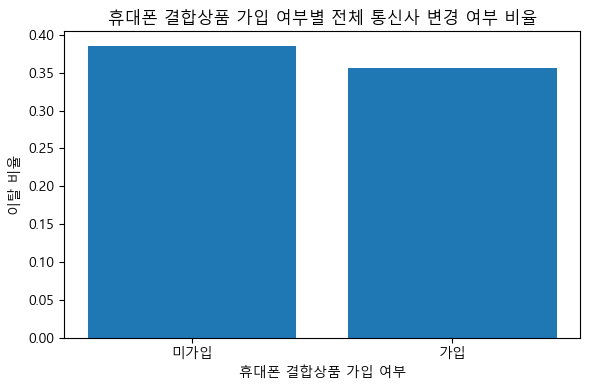


[직업 유무 - 전체 통신사 변경 여부]


,구분,이탈 비율
0,직업 없음,0.353668
1,직업 있음,0.368641


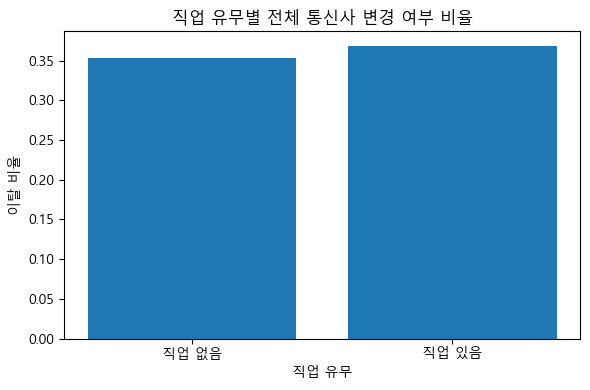


[음성 무제한 서비스 가입 여부 - 메이저 → 알뜰폰 이동 여부]


,구분,이탈 비율
0,미가입,0.011233
1,가입,0.012972


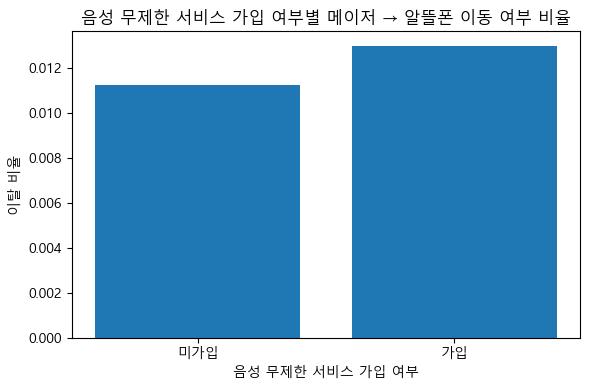


[데이터 무제한 서비스 가입 여부 - 메이저 → 알뜰폰 이동 여부]


,구분,이탈 비율
0,미가입,0.013053
1,가입,0.011491


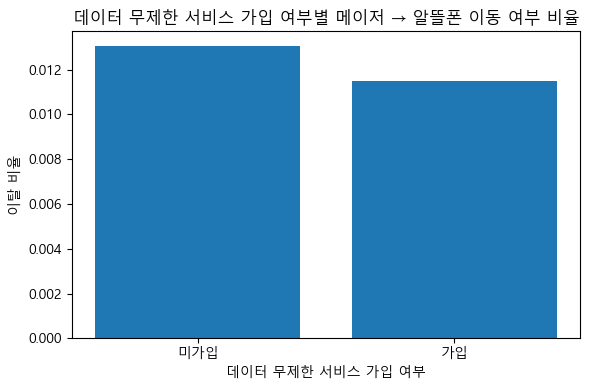


[휴대폰 결합상품 가입 여부 - 메이저 → 알뜰폰 이동 여부]


,구분,이탈 비율
0,미가입,0.018108
1,가입,0.010696


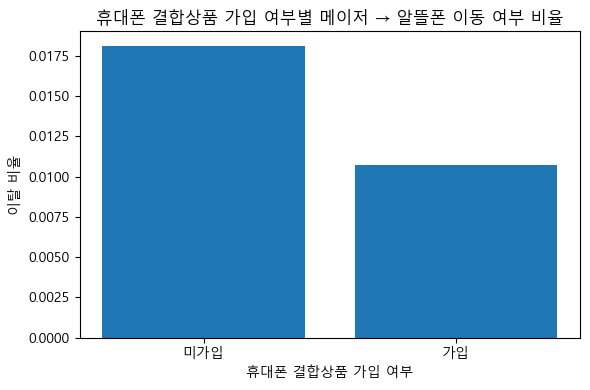


[직업 유무 - 메이저 → 알뜰폰 이동 여부]


,구분,이탈 비율
0,직업 없음,0.014139
1,직업 있음,0.011393


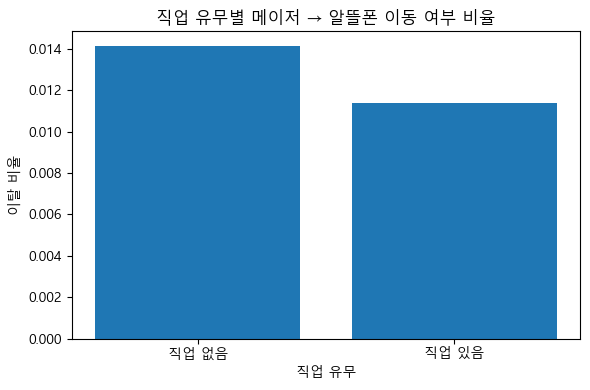

In [9]:
# ============================================================
# 추가. 이진형 변수별 이탈률 비교
# ============================================================
binary_like_cols = [
    "a03024_tminus1",
    "a03026_tminus1",
    "c02003_tminus1",
    "job1_tminus1"
]

job_map = {
    0: "직업 없음",
    1: "직업 있음"
}

binary_map = {
    0: "미가입",
    1: "가입"
}

for target in ["churn_any", "churn_to_mvno"]:
    for col in binary_like_cols:
        rate_df = (
            df.groupby(col)[target]
            .mean()
            .reset_index(name="이탈 비율")
            .sort_values(col)
        )

        if col == "job1_tminus1":
            rate_df["구분"] = rate_df[col].map(job_map)
        else:
            rate_df["구분"] = rate_df[col].map(binary_map)

        display_df = rate_df[["구분", "이탈 비율"]].copy()
        print(f"\n[{rename_feature_label(col)} - {TARGET_LABEL_MAP[target]}]")
        display(display_df)

        plt.figure(figsize=(6, 4))
        plt.bar(display_df["구분"], display_df["이탈 비율"])
        plt.title(f"{rename_feature_label(col)}별 {TARGET_LABEL_MAP[target]} 비율")
        plt.xlabel(rename_feature_label(col))
        plt.ylabel("이탈 비율")
        plt.tight_layout()
        plt.show()

## [ 해석 ]

이진형 변수별 이탈률 비교를 통해 서비스 가입 여부나 직업 유무에 따라 라벨별 차이가 나타나는지 확인할 수 있다.

이 단계에서는 평균값보다 각 집단의 이탈 비율 차이를 보는 것이 더 적절하다.

특히 음성 무제한 서비스 가입 여부, 데이터 무제한 서비스 가입 여부, 휴대폰 결합상품 가입 여부, 직업 유무와 같은 변수들은 이후 모델에서 이탈 가능성을 설명하는 보조 신호로 작용할 수 있다.

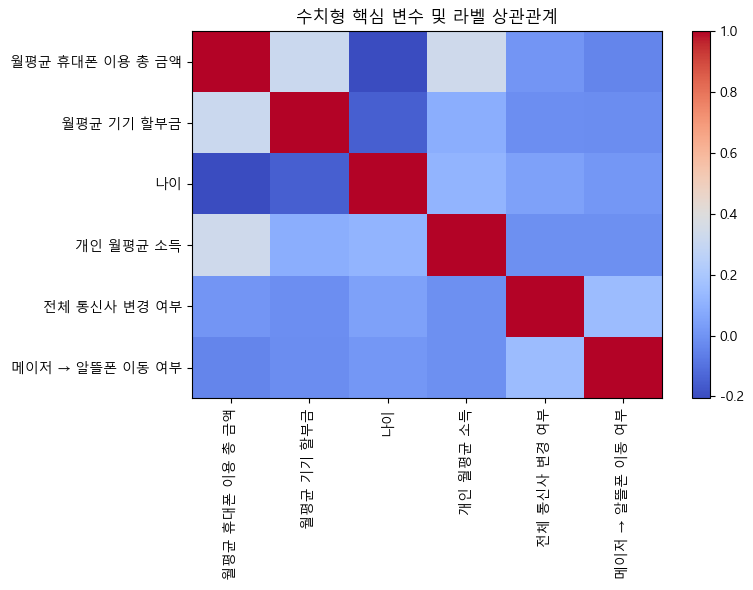

In [10]:
# ============================================================
# 8. 상관관계 확인
# ============================================================
corr_feature_cols = [
    "c01002_tminus1",
    "c01004_tminus1",
    "age1_tminus1",
    "income1_tminus1",
    "churn_any",
    "churn_to_mvno"
]

corr_df = df[corr_feature_cols].corr()

corr_display_df = corr_df.copy()
corr_display_df.index = [FEATURE_LABEL_MAP.get(idx, TARGET_LABEL_MAP.get(idx, idx)) for idx in corr_display_df.index]
corr_display_df.columns = [FEATURE_LABEL_MAP.get(col, TARGET_LABEL_MAP.get(col, col)) for col in corr_display_df.columns]

plt.figure(figsize=(8, 6))
plt.imshow(corr_display_df, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_display_df.columns)), corr_display_df.columns, rotation=90)
plt.yticks(range(len(corr_display_df.index)), corr_display_df.index)
plt.title("수치형 핵심 변수 및 라벨 상관관계")
plt.tight_layout()
plt.show()

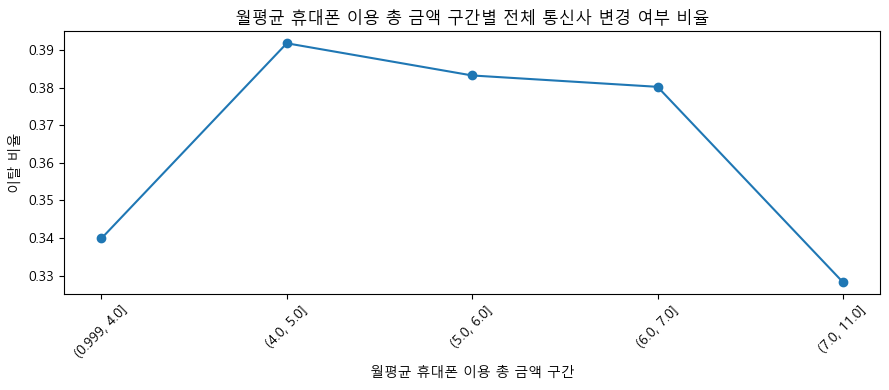

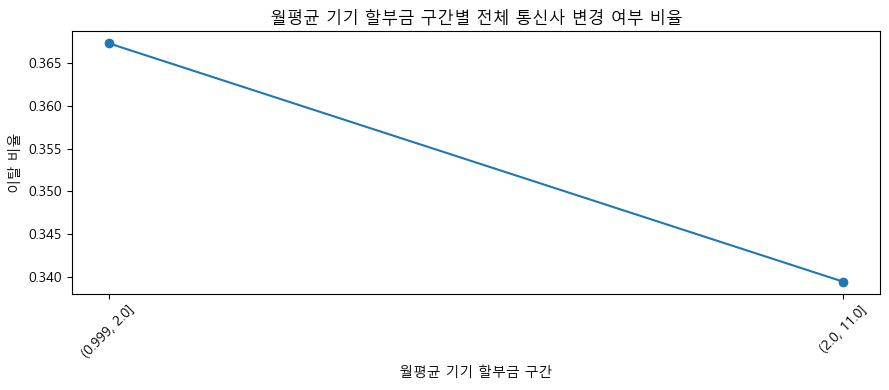

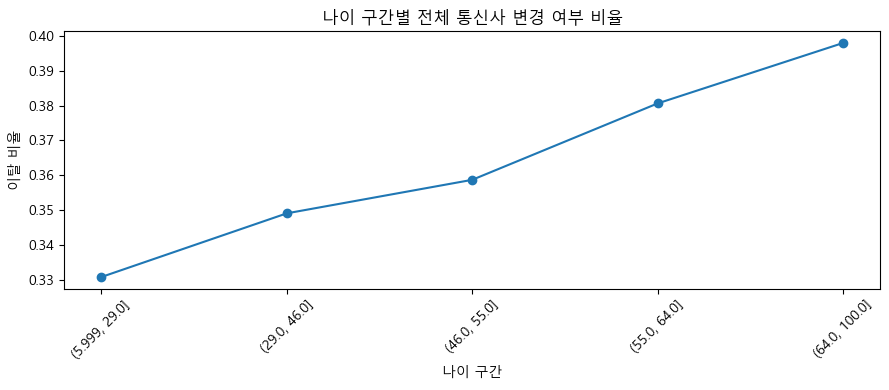

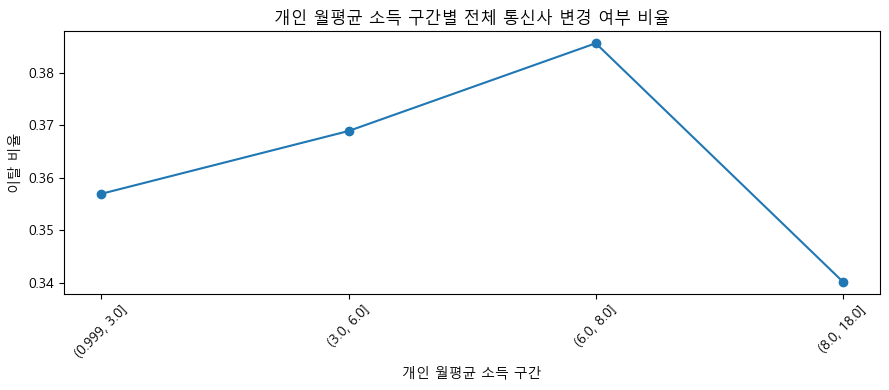

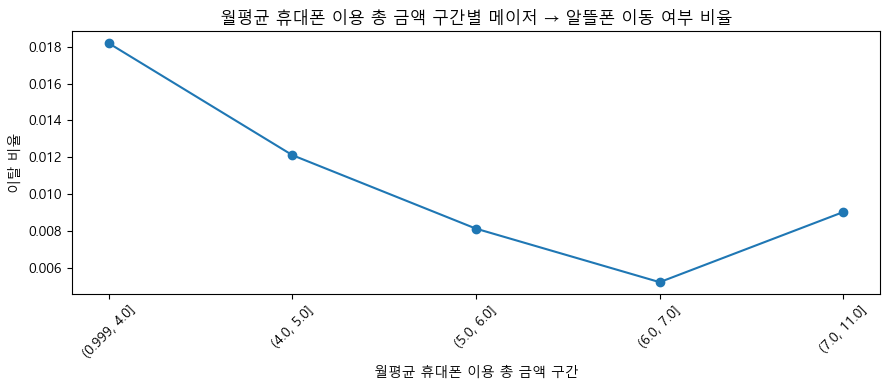

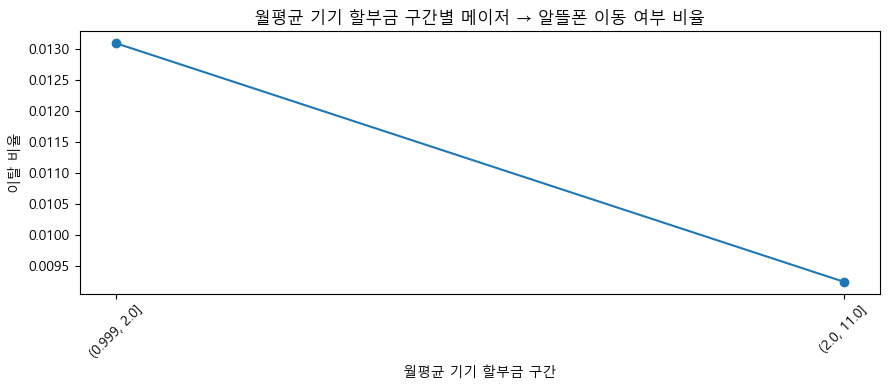

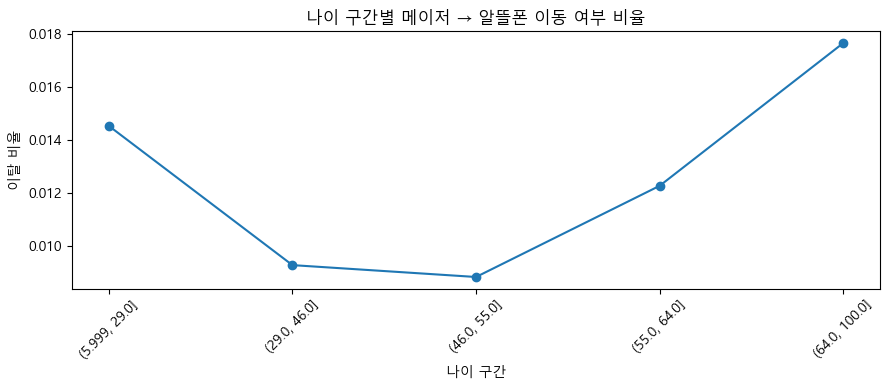

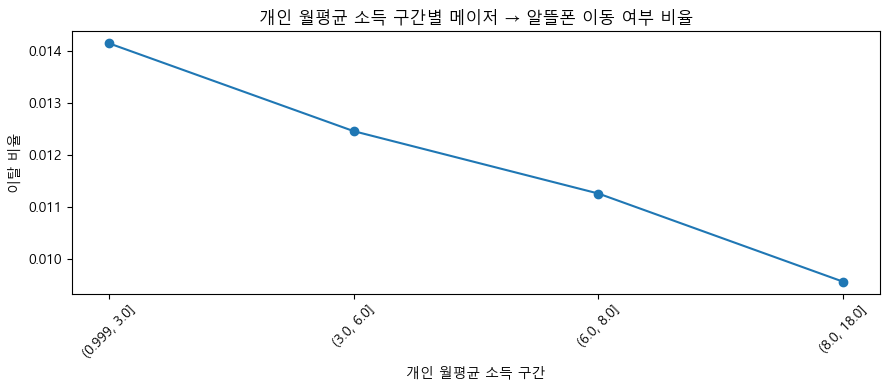

In [11]:
# ============================================================
# 추가. 수치형 변수 구간별 이탈률 비교
# ============================================================
rate_feature_cols = [
    "c01002_tminus1",
    "c01004_tminus1",
    "age1_tminus1",
    "income1_tminus1"
]

for target in ["churn_any", "churn_to_mvno"]:
    for col in rate_feature_cols:
        temp_df = df[[col, target]].copy()
        temp_df["bin"] = pd.qcut(temp_df[col], q=5, duplicates="drop")

        rate_df = (
            temp_df.groupby("bin", observed=False)[target]
            .mean()
            .reset_index(name="churn_rate")
        )

        plt.figure(figsize=(9, 4))
        plt.plot(rate_df["bin"].astype(str), rate_df["churn_rate"], marker="o")
        plt.title(f"{rename_feature_label(col)} 구간별 {TARGET_LABEL_MAP[target]} 비율")
        plt.xlabel(rename_feature_label(col) + " 구간")
        plt.ylabel("이탈 비율")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

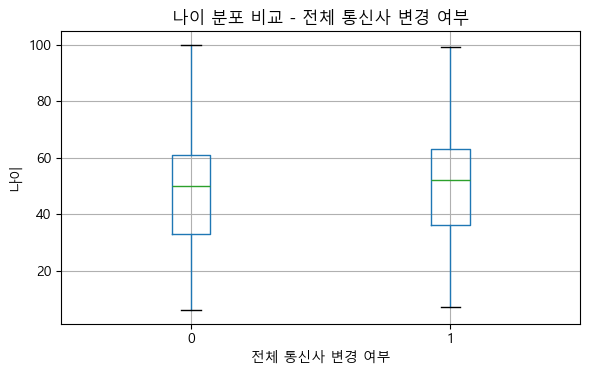

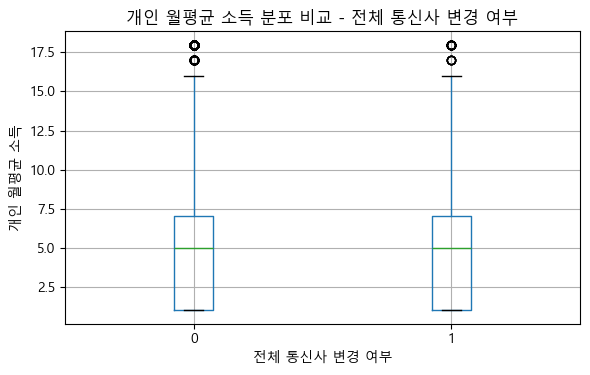


[직업 유무 - 전체 통신사 변경 여부]


,구분,이탈 비율
0,직업 없음,0.353668
1,직업 있음,0.368641


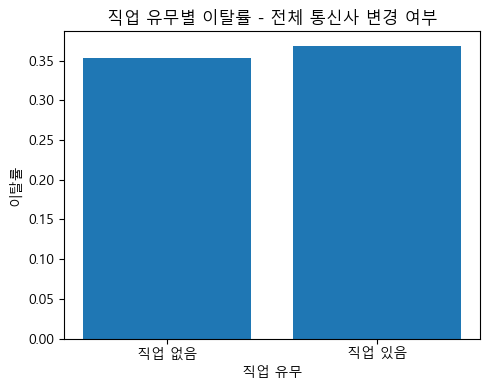

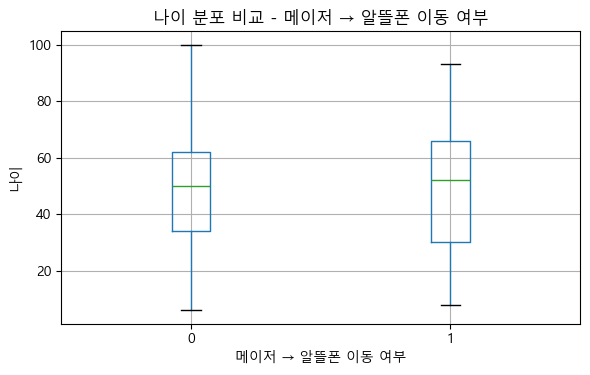

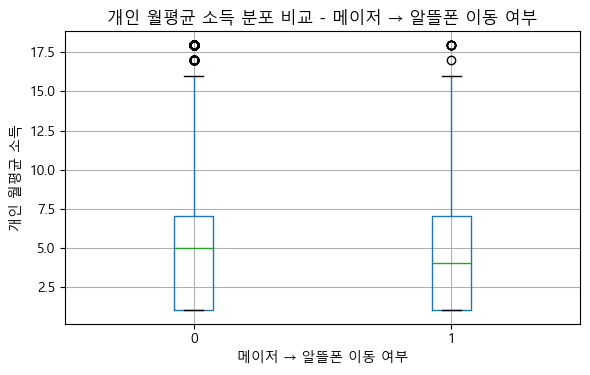


[직업 유무 - 메이저 → 알뜰폰 이동 여부]


,구분,이탈 비율
0,직업 없음,0.014139
1,직업 있음,0.011393


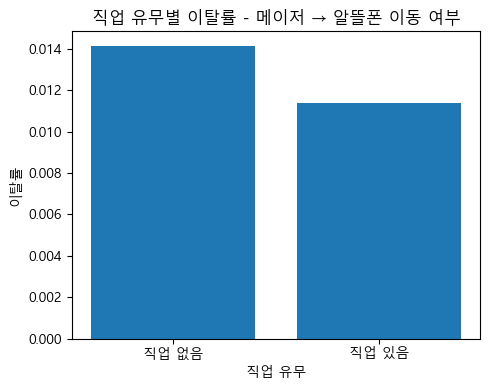

In [12]:
# ============================================================
# 추가. 새 변수 중심 EDA
# ============================================================
job_map = {
    0: "직업 없음",
    1: "직업 있음"
}

for target in ["churn_any", "churn_to_mvno"]:
    fig, ax = plt.subplots(figsize=(6, 4))
    df.boxplot(column="age1_tminus1", by=target, ax=ax)
    ax.set_title(f"나이 분포 비교 - {TARGET_LABEL_MAP[target]}")
    fig.suptitle("")
    ax.set_xlabel(TARGET_LABEL_MAP[target])
    ax.set_ylabel("나이")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    df.boxplot(column="income1_tminus1", by=target, ax=ax)
    ax.set_title(f"개인 월평균 소득 분포 비교 - {TARGET_LABEL_MAP[target]}")
    fig.suptitle("")
    ax.set_xlabel(TARGET_LABEL_MAP[target])
    ax.set_ylabel("개인 월평균 소득")
    plt.tight_layout()
    plt.show()

    rate_df = (
        df.groupby("job1_tminus1")[target]
        .mean()
        .reset_index(name="이탈 비율")
        .sort_values("job1_tminus1")
    )
    rate_df["구분"] = rate_df["job1_tminus1"].map(job_map)

    print(f"\n[직업 유무 - {TARGET_LABEL_MAP[target]}]")
    display(rate_df[["구분", "이탈 비율"]])

    plt.figure(figsize=(5, 4))
    plt.bar(rate_df["구분"], rate_df["이탈 비율"])
    plt.title(f"직업 유무별 이탈률 - {TARGET_LABEL_MAP[target]}")
    plt.xlabel("직업 유무")
    plt.ylabel("이탈률")
    plt.tight_layout()
    plt.show()

## [ 해석 ]

새로 추가한 개인 배경 변수인 나이, 개인 월평균 소득, 직업 유무를 중심으로 보면 라벨별 분포 차이를 추가로 확인할 수 있다.

나이와 개인 월평균 소득은 연속형 수치 변수이므로 boxplot을 활용한 분포 비교와 함께 구간별 이탈률을 분석하여 집단 간 차이를 확인하는 것이 적절하다.

반면 직업 유무는 이진형 변수이므로 직업이 있는 집단과 없는 집단의 이탈률을 직접 비교하는 방식이 더 자연스럽다.

특히 `churn_to_mvno`와 같은 희소 라벨 문제에서는 연령, 소득, 직업과 같은 개인 배경 변수도 함께 살펴볼 필요가 있으며, 실제 예측 기여도는 이후 모델링 단계에서 다시 확인하는 것이 적절하다.



In [13]:
# ============================================================
# 9. EDA 핵심 요약
# ============================================================
print("전체 데이터 shape:", df.shape)
print("churn_any 양성 비율:", round(df["churn_any"].mean(), 4))
print("churn_to_mvno 양성 비율:", round(df["churn_to_mvno"].mean(), 4))
print("\n[해석]")
print("- churn_any는 비교적 예측 가능한 수준의 양성 비율을 보였고, churn_to_mvno는 매우 희소한 이벤트로 확인되었다.")
print("- 따라서 churn_to_mvno는 Accuracy보다 Recall, F1, PR-AUC 중심 해석이 더 중요하다.")
print("- 또한 나이, 개인 월평균 소득, 직업 유무와 같은 개인 배경 변수도 이후 모델에서 보조적인 설명 변수로 작용할 가능성이 있다.")

전체 데이터 shape: (41299, 17)
churn_any 양성 비율: 0.3628
churn_to_mvno 양성 비율: 0.0125

[해석]
- churn_any는 비교적 예측 가능한 수준의 양성 비율을 보였고, churn_to_mvno는 매우 희소한 이벤트로 확인되었다.
- 따라서 churn_to_mvno는 Accuracy보다 Recall, F1, PR-AUC 중심 해석이 더 중요하다.
- 또한 나이, 개인 월평균 소득, 직업 유무와 같은 개인 배경 변수도 이후 모델에서 보조적인 설명 변수로 작용할 가능성이 있다.


## [ EDA 요약 ]

이번 EDA를 통해 전처리된 데이터셋의 기본 구조와 라벨 분포, 핵심 변수 분포를 확인하였다.

첫째, 데이터는 `pid` 기준 전환형 long panel 구조로 정상적으로 구성되어 있었으며, 연도 간 전환 구간에 따른 데이터 흐름을 확인 가능했다.

둘째, `churn_any`는 약 36% 수준의 양성 비율을 보여 상대적으로 표본이 충분한 문제였고, `churn_to_mvno`는 약 1% 수준의 매우 희소한 이벤트로 나타나 두 예측 과제의 난이도 차이가 큼을 확인할 수 있었다.

셋째, 기존 통신 이용 특성 변수에 더해 나이, 개인 월평균 소득, 직업 유무를 함께 확인함으로써, 통신 사용 패턴뿐 아니라 개인의 사회경제적 특성도 이탈과 관련될 가능성을 살펴볼 수 있었다.

넷째, 비용 관련 변수와 일부 서비스 가입 여부, 개인 배경 변수는 라벨별 분포 차이나 이탈률 차이를 보여 이후 baseline 모델에서 함께 확인할 필요가 있는 후보 변수임을 시사하였다.

즉, 본 EDA는 모델링에 앞서 데이터의 구조와 라벨, 특성, 주요 변수들의 분포 차이를 사전에 점검함으로써 이후 분석 결과를 해석하기 위한 기초적인 이해를 제공하는 단계로서 의미가 있다.